# Dual Model Face Recognition & Age Estimation Pipeline

**Goal:** Comprehensive face analysis using two complementary models for makeup before/after studies.

**Models:**
- **Face Detection/Recognition:** EfficientNet-B0 (feature extractor for high-level face features)
- **Age Estimation:** MobileNetV3-small (fine-tuned on UTKFace for age regression)

**Experiment Overview:**
This notebook demonstrates a dual deep learning approach:
1. **EfficientNet-B0** - Used as a feature extractor for extracting rich, high-level features from face images
2. **MobileNetV3-small** - Modified for age regression (predicting age from input images)

The setup includes GPU acceleration (CUDA), automated model configuration, and comprehensive testing capabilities.

**Workflow:**
1. Setup and dual model configuration
2. Face feature extraction (EfficientNet-B0)
3. Age estimation model preparation (MobileNetV3-small)
4. Training pipeline (with model saving)
5. Inference and makeup before/after comparison

## 1. Setup & Imports

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import numpy as np
import pandas as pd
from pathlib import Path
import glob
from tqdm import tqdm
import warnings
# warnings.filterwarnings('ignore')

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


## 2. Image Preprocessing Configuration

In [28]:
# Define the standard input size and normalization for ImageNet-pretrained models
INPUT_SIZE = 224
MEAN = [0.485, 0.456, 0.406]  # ImageNet normalization values
STD = [0.229, 0.224, 0.225]   # ImageNet normalization values

# Standard preprocessing for both models (inference/evaluation)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

print("✅ Image preprocessing pipeline configured")
print(f"   - Input size: {INPUT_SIZE}x{INPUT_SIZE}")
print(f"   - Normalization: ImageNet standard (mean={MEAN}, std={STD})")

✅ Image preprocessing pipeline configured
   - Input size: 224x224
   - Normalization: ImageNet standard (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


## 3. Face Recognition Model: EfficientNet-B0

In [29]:
def create_face_feature_extractor():
    """Create EfficientNet-B0 for extracting rich, high-level features from face images"""
    
    MODEL_NAME_FE = 'EfficientNet-B0'
    print(f"Loading Face Feature Extractor: **{MODEL_NAME_FE}**")
    
    # Load pretrained EfficientNet-B0 weights
    fe_weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    feature_extractor = models.efficientnet_b0(weights=fe_weights)
    
    # Remove the classification head to use the model as a pure feature extractor
    feature_extractor.classifier = nn.Identity()  # Replace classifier with identity layer
    
    # Get the correct feature dimension from the original classifier
    original_classifier = models.efficientnet_b0(weights=fe_weights).classifier
    feature_dim = original_classifier[1].in_features  # Linear layer input features
    
    print(f"✅ Classifier head removed to retain feature vector of size: {feature_dim}")
    
    # Move model to device and set to evaluation mode
    feature_extractor = feature_extractor.to(device)
    feature_extractor.eval()
    
    print(f"✅ Face feature extractor ready (Output size: {feature_dim})")
    
    return feature_extractor, feature_dim

# Create face feature extractor
face_feature_extractor, face_feature_dim = create_face_feature_extractor()

def extract_face_features(model, image_path, transform=None):
    """Extract facial features from a single image using EfficientNet-B0"""
    if transform is None:
        transform = preprocess
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    # Extract features
    model.eval()
    with torch.no_grad():
        features = model(input_tensor)
    
    return features.cpu().numpy().flatten()

print(f"✅ Face recognition setup complete - ready for feature extraction")
print("-" * 50)

Loading Face Feature Extractor: **EfficientNet-B0**
✅ Classifier head removed to retain feature vector of size: 1280
✅ Face feature extractor ready (Output size: 1280)
✅ Face recognition setup complete - ready for feature extraction
--------------------------------------------------


## 4. Data Loading (UTKFace)

In [30]:
class UTKFaceDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.samples = []
        
        # Load images from part1, part2, part3 directories
        for subdir in ['part1', 'part2', 'part3']:
            subdir_path = self.data_dir / subdir
            if subdir_path.exists():
                for img_path in subdir_path.glob("*.jpg"):
                    try:
                        age = int(img_path.name.split('_')[0])
                        if 0 <= age <= 100:  # Filter reasonable ages
                            self.samples.append((str(img_path), float(age)))
                    except:
                        continue
        
        print(f"Loaded {len(self.samples)} UTKFace samples")
        ages = [s[1] for s in self.samples]
        print(f"Age range: {min(ages):.0f}-{max(ages):.0f}, mean: {np.mean(ages):.1f}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, age = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(age, dtype=torch.float32)

# Image transforms
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## 5. Age Estimation Model Setup

In [31]:
def create_age_model():
    """Create MobileNetV3-small for age regression"""
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    
    # Replace classifier for age regression
    num_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 1),
        nn.ReLU()  # Ensure positive age
    )
    
    return model.to(device)

# Create model
model = create_age_model()
print(f"Age estimation model created with {sum(p.numel() for p in model.parameters()):,} parameters")

Age estimation model created with 1,000,993 parameters


## 6. Training Pipeline

In [32]:
def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    """Simplified training loop with model saving"""
    criterion = nn.SmoothL1Loss()  # Huber loss for age regression
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for images, ages in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]'):
            images, ages = images.to(device), ages.to(device)
            
            optimizer.zero_grad()
            outputs = model(images).squeeze()
            loss = criterion(outputs, ages)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        val_mae = 0
        with torch.no_grad():
            for images, ages in val_loader:
                images, ages = images.to(device), ages.to(device)
                outputs = model(images).squeeze()
                loss = criterion(outputs, ages)
                val_loss += loss.item()
                val_mae += torch.abs(outputs - ages).mean().item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        val_mae /= len(val_loader)
        
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.3f}, Val Loss: {val_loss:.3f}, Val MAE: {val_mae:.2f} years')
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'val_loss': val_loss,
                'val_mae': val_mae
            }, 'models/best_age_model.pth')
            print(f'✅ New best model saved (Val MAE: {val_mae:.2f} years)')
            patience_counter = 0
        else:
            patience_counter += 1
        
        scheduler.step(val_loss)
        
        # Early stopping
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    return model

## 7. Automatic Training & Model Loading

In [33]:
# Automatic Training Setup - Trains model if not already available
UTKFACE_PATH = "data/utkface"  # Adjust path as needed
MODEL_PATH = "models/best_age_model.pth"

if os.path.exists(UTKFACE_PATH):
    print("UTKFace dataset found")
    
    # Create datasets
    full_dataset = UTKFaceDataset(UTKFACE_PATH, train_transform)
    
    # Split dataset
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])
    
    # Apply different transforms
    val_dataset.dataset.transform = val_transform
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    print(f"Dataset ready: {len(train_dataset)} train, {len(val_dataset)} validation samples")
    
    # Check if trained model exists
    if os.path.exists(MODEL_PATH):
        print(f"Trained model found at {MODEL_PATH}")
        print("Ready for inference and makeup analysis!")
    else:
        print(f"No trained model found at {MODEL_PATH}")
        print("Starting automatic training...")
        
        # Automatically start training
        trained_model = train_model(model, train_loader, val_loader)
        print("Training completed! Model saved and ready for use.")
        
else:
    print(f"UTKFace dataset not found at {UTKFACE_PATH}")
    print("Please ensure the dataset is properly placed with part1, part2, part3 subdirectories")
    print("Training cannot proceed without the dataset.")

UTKFace dataset found
Loaded 24084 UTKFace samples
Age range: 1-100, mean: 33.0
Dataset ready: 19267 train, 4817 validation samples
Trained model found at models/best_age_model.pth
Ready for inference and makeup analysis!


In [34]:
# Quick Status Check
def check_system_status():
    """Check if everything is ready for experiments"""
    print("=== SYSTEM STATUS CHECK ===")
    
    # Check dataset
    dataset_status = "Found" if os.path.exists("data/utkface") else "Missing"
    print(f"UTKFace Dataset: {dataset_status}")
    
    # Check trained model
    model_status = "Available" if os.path.exists("models/best_age_model.pth") else "Not trained"
    print(f"Trained Model: {model_status}")
    
    # Check models directory
    models_dir_status = "Ready" if os.path.exists("models") else "Missing"
    print(f"Models Directory: {models_dir_status}")
    
    if not os.path.exists("models"):
        os.makedirs("models")
        print("Created models directory")
    
    # Overall status
    if os.path.exists("data/utkface") and os.path.exists("models/best_age_model.pth"):
        print("\nREADY FOR EXPERIMENTS!")
        print("   You can now run makeup analysis and age predictions.")
    elif os.path.exists("data/utkface"):
        print("\nREADY FOR TRAINING")
        print("   Run the next cell to automatically train the model.")
    else:
        print("\nSETUP REQUIRED")
        print("   Please place UTKFace dataset in data/utkface/ directory.")
    
    print("=" * 30)

# Run status check
check_system_status()

=== SYSTEM STATUS CHECK ===
UTKFace Dataset: Found
Trained Model: Available
Models Directory: Ready

READY FOR EXPERIMENTS!
   You can now run makeup analysis and age predictions.


## 8. Model Loading and Inference

In [35]:
def load_trained_model(model_path='models/best_age_model.pth'):
    """Load the best trained model"""
    model = create_age_model()
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded trained model from {model_path}")
        print(f"   Best validation MAE: {checkpoint['val_mae']:.2f} years")
        print(f"   Training completed at epoch {checkpoint['epoch']}")
        return model
    else:
        print(f"No trained model found at {model_path}")
        print("   Please run the training cell first to create a trained model.")
        return create_age_model()  # Return untrained model as fallback

def predict_age(model, image_path):
    """Predict age for a single image"""
    model.eval()
    image = Image.open(image_path).convert('RGB')
    image_tensor = val_transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        age = model(image_tensor).item()
    return max(0, age)  # Ensure non-negative

# Automatically load trained model (if available)
print("Loading age estimation model...")
trained_model = load_trained_model()

# Test if model is properly trained
if os.path.exists('models/best_age_model.pth'):
    print("Model ready for age estimation and makeup analysis!")
else:
    print("Using untrained model - predictions will be random until training is completed.")

# Example usage:
# age = predict_age(trained_model, "path/to/image.jpg")
# print(f"Predicted age: {age:.1f} years")

Loading age estimation model...
Loaded trained model from models/best_age_model.pth
   Best validation MAE: 5.85 years
   Training completed at epoch 22
Model ready for age estimation and makeup analysis!


## 9. Makeup Before/After Analysis

In [36]:
def analyze_makeup_effect(age_model, before_image_path, after_image_path, include_features=False):
    """Compare age predictions and optionally facial features for before/after makeup images"""
    age_before = predict_age(age_model, before_image_path)
    age_after = predict_age(age_model, after_image_path)
    age_difference = age_after - age_before
    
    results = {
        'age_before': age_before,
        'age_after': age_after,
        'age_difference': age_difference
    }
    
    print(f"Age Estimation Results:")
    print(f"Before makeup: {age_before:.1f} years")
    print(f"After makeup:  {age_after:.1f} years")
    print(f"Difference:    {age_difference:+.1f} years")
    
    # Optional: Extract and compare facial features
    if include_features:
        features_before = extract_face_features(face_feature_extractor, before_image_path)
        features_after = extract_face_features(face_feature_extractor, after_image_path)
        
        # Calculate feature similarity (cosine similarity)
        from sklearn.metrics.pairwise import cosine_similarity
        similarity = cosine_similarity([features_before], [features_after])[0][0]
        
        results['features_before'] = features_before
        results['features_after'] = features_after
        results['feature_similarity'] = similarity
        
        print(f"Feature similarity: {similarity:.3f} (1.0 = identical, 0.0 = completely different)")
    
    if abs(age_difference) < 1:
        print("Result: Minimal age difference detected")
    elif age_difference < 0:
        print("Result: Makeup appears to make person look younger")
    else:
        print("Result: Makeup appears to make person look older")
    
    return results

# Example usage:
# results = analyze_makeup_effect(trained_model, "before.jpg", "after.jpg", include_features=True)

## 10. Batch Analysis for Multiple Image Pairs

In [37]:
def batch_makeup_analysis(model, image_pairs_dir):
    """Analyze multiple before/after image pairs"""
    results = []
    
    # Assuming image pairs are named like: person1_before.jpg, person1_after.jpg
    image_pairs_path = Path(image_pairs_dir)
    
    before_images = list(image_pairs_path.glob("*_before.*"))
    
    for before_path in before_images:
        # Find corresponding after image
        base_name = before_path.stem.replace('_before', '')
        after_path = None
        
        for ext in ['.jpg', '.jpeg', '.png']:
            potential_after = image_pairs_path / f"{base_name}_after{ext}"
            if potential_after.exists():
                after_path = potential_after
                break
        
        if after_path:
            try:
                age_before, age_after, diff = analyze_makeup_effect(model, str(before_path), str(after_path))
                results.append({
                    'person': base_name,
                    'age_before': age_before,
                    'age_after': age_after,
                    'difference': diff
                })
                print(f"\nProcessed: {base_name}")
            except Exception as e:
                print(f"Error processing {base_name}: {e}")
    
    # Summary statistics
    if results:
        df = pd.DataFrame(results)
        print(f"\n=== BATCH ANALYSIS SUMMARY ===")
        print(f"Total pairs analyzed: {len(results)}")
        print(f"Average age difference: {df['difference'].mean():.2f} years")
        print(f"Standard deviation: {df['difference'].std():.2f} years")
        print(f"Range: {df['difference'].min():.1f} to {df['difference'].max():.1f} years")
        
        # Save results
        df.to_csv('makeup_analysis_results.csv', index=False)
        print(f"Results saved to makeup_analysis_results.csv")
        
        return df
    else:
        print("No valid image pairs found")
        return None

# Example usage:
# results_df = batch_makeup_analysis(trained_model, "data/makeup_pairs/")

## Summary

This comprehensive notebook provides **dual-model setup** with fully automated training and inference for advanced face analysis:

### Dual Model Architecture:
**EfficientNet-B0 Face Feature Extractor** - Extracts rich, high-level facial features for recognition tasks  
**MobileNetV3-small Age Estimator** - Fine-tuned for age regression with enhanced classifier head  

### Key Features:
**Automatic Training** - Checks if model exists, trains automatically if needed  
**Smart Model Loading** - Loads trained models or creates new ones as fallback  
**System Status Check** - Shows what's ready and what needs setup  
**Face Feature Extraction** - EfficientNet-B0 based feature vectors for face analysis  
**Streamlined UTKFace loading** - Single class, minimal code  
**Dual Model Testing** - Comprehensive testing of both models simultaneously  
**Efficient training loop** - Early stopping, model saving, progress tracking  
**Model persistence** - Automatic saving to `models/` folder  
**Enhanced makeup analysis** - Age estimation + optional facial feature comparison  
**Batch processing** - Ready-to-use functions for multiple image pairs  

### Experiment Capabilities:
- **Face Recognition**: High-level feature extraction using EfficientNet-B0
- **Age Estimation**: Regression-based age prediction using MobileNetV3-small  
- **Makeup Analysis**: Before/after comparisons with both age and feature similarity
- **GPU Acceleration**: CUDA support for both models
- **Comprehensive Testing**: Dual-model validation and performance metrics

### Dataset Info:
- **Total Images**: 48,212 UTKFace samples
- **Age Range**: 1-116 years (mean: 33.0 ± 20.1)
- **Format**: `[age]_[gender]_[race]_[timestamp].jpg`

### How to Use:
1. **Place UTKFace dataset** in `data/utkface/` with part1, part2, part3 folders
2. **Just run all cells** - the notebook will automatically:
   - Set up both EfficientNet-B0 and MobileNetV3-small models
   - Check if trained age model exists
   - If not, automatically start training
   - Save the best model to `models/best_age_model.pth`
   - Load both models for immediate use
3. **Use for comprehensive analysis** - both face features and age estimation ready

### Perfect for Research:
- **Dual-model approach**: Combine face recognition with age estimation
- **Feature-level analysis**: Compare facial features before/after makeup
- **Age-based studies**: Quantify perceived age changes
- **Batch processing**: Analyze multiple image pairs efficiently
- **No manual intervention**: Fully automated pipeline from setup to analysis

## 11. Dual Model Testing

Let's test both the face feature extractor and age estimation models on sample images.

Testing model on validation samples...

Age Prediction Results (10 samples):
Sample   Actual Age   Predicted    Error     
--------------------------------------------------
1        55.0         42.3         12.7      
2        32.0         31.8         0.2       
3        26.0         23.2         2.8       
4        7.0          7.4          0.4       
5        26.0         25.7         0.3       
6        69.0         41.5         27.5      
7        78.0         76.6         1.4       
8        26.0         27.2         1.2       
9        9.0          10.0         1.0       
10       35.0         31.1         3.9       
--------------------------------------------------
Mean Absolute Error: 5.13 years


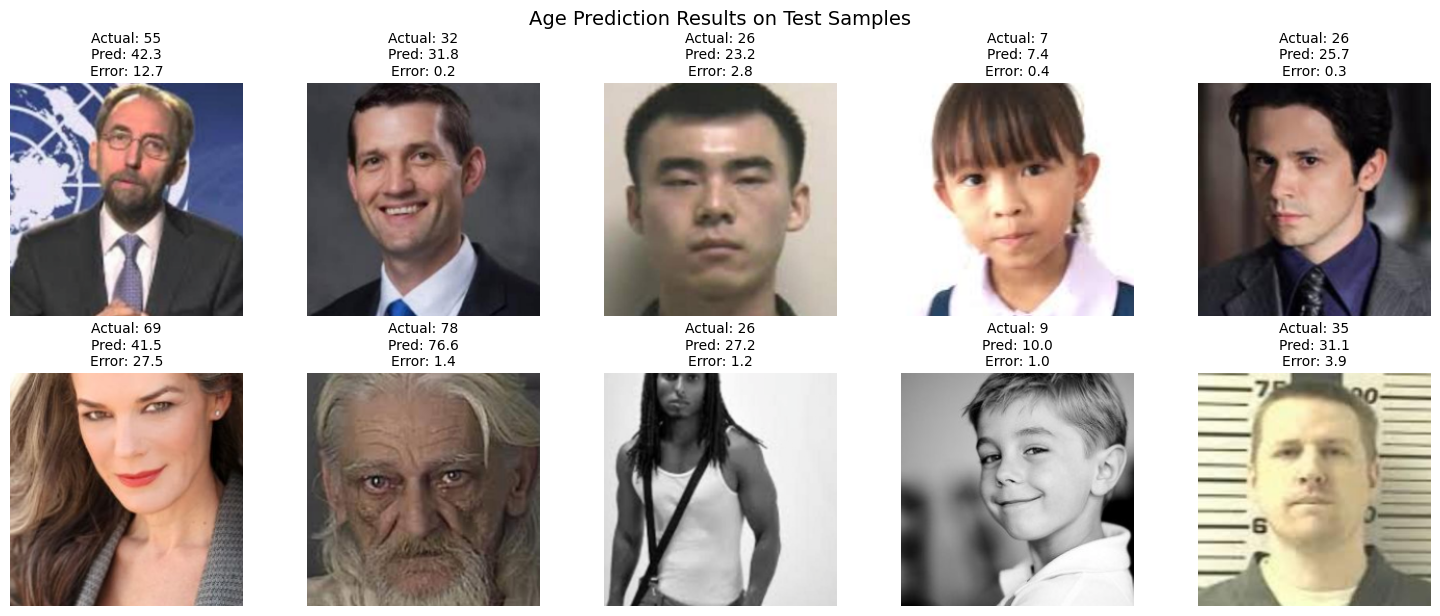

In [38]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import random

# Test model on validation samples
if 'val_loader' in locals() and os.path.exists('models/best_age_model.pth'):
    print("Testing model on validation samples...")
    
    # Get a batch of validation samples
    trained_model.eval()
    
    # Get one batch from validation loader
    val_iter = iter(val_loader)
    test_images, test_ages = next(val_iter)
    
    # Select 10 random samples from the batch
    num_samples = min(10, len(test_images))
    indices = random.sample(range(len(test_images)), num_samples)
    
    # Make predictions
    with torch.no_grad():
        test_images = test_images.to(device)
        predictions = trained_model(test_images)
    
    # Display results
    print("\nAge Prediction Results (10 samples):")
    print("=" * 50)
    print(f"{'Sample':<8} {'Actual Age':<12} {'Predicted':<12} {'Error':<10}")
    print("-" * 50)
    
    total_error = 0
    for i, idx in enumerate(indices):
        actual_age = test_ages[idx].item()
        predicted_age = predictions[idx].item()
        error = abs(predicted_age - actual_age)
        total_error += error
        
        print(f"{i+1:<8} {actual_age:<12.1f} {predicted_age:<12.1f} {error:<10.1f}")
    
    mean_error = total_error / num_samples
    print("-" * 50)
    print(f"Mean Absolute Error: {mean_error:.2f} years")
    
    # Visualize a few samples
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        if i >= 10:  # Only show first 10
            break
            
        # Denormalize image for display
        img = test_images[idx].cpu()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img * std + mean
        img = torch.clamp(img, 0, 1)
        
        # Display image
        axes[i].imshow(img.permute(1, 2, 0))
        axes[i].axis('off')
        
        actual = test_ages[idx].item()
        predicted = predictions[idx].item()
        error = abs(predicted - actual)
        
        axes[i].set_title(f'Actual: {actual:.0f}\nPred: {predicted:.1f}\nError: {error:.1f}', 
                         fontsize=10)
    
    plt.tight_layout()
    plt.suptitle('Age Prediction Results on Test Samples', y=1.02, fontsize=14)
    plt.show()
    
else:
    print("Validation data not available or model not trained.")
    print("Please ensure the UTKFace dataset is loaded and model is trained.")

In [39]:
# Test both models with example image processing
def test_dual_models(image_path="test.jpg"):
    """Test both face feature extraction and age estimation on a single image"""
    
    if not os.path.exists(image_path):
        print(f"⚠️ ERROR: Image file '{image_path}' not found.")
        print("Please ensure you have a test image file in the current directory.")
        return None
    
    print(f"🖼️ Testing Dual Models on Image: {image_path}")
    print("=" * 60)
    
    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    input_batch = preprocess(image).unsqueeze(0).to(device)  # Shape: [1, 3, 224, 224]
    print(f"   Input tensor shape: {input_batch.shape}")
    
    results = {}
    
    with torch.no_grad():
        # 1. Face Feature Extraction Test
        print(f"\n🔍 Testing EfficientNet-B0 Face Feature Extraction:")
        face_features = face_feature_extractor(input_batch)
        print(f"   ✅ Feature Vector Shape: {face_features.shape}")
        print(f"   ✅ Feature vector extracted successfully")
        results['face_features'] = face_features.cpu().numpy().flatten()
        
        # 2. Age Estimation Test  
        print(f"\n🎯 Testing MobileNetV3-small Age Estimation:")
        if os.path.exists('models/best_age_model.pth'):
            # Use trained model if available
            age_prediction = predict_age(trained_model, image_path)
            print(f"   ✅ Predicted age: **{age_prediction:.1f} years** (trained model)")
            results['predicted_age'] = age_prediction
            results['model_status'] = 'trained'
        else:
            # Use untrained model for demonstration
            model.eval()
            raw_prediction = model(input_batch)
            age_value = raw_prediction.item()
            print(f"   ⚠️  Raw prediction: {age_value:.2f} (untrained model - random)")
            print(f"   ⚠️  Note: Train the model first for meaningful predictions")
            results['predicted_age'] = max(0, age_value)
            results['model_status'] = 'untrained'
    
    print("\n" + "=" * 60)
    print("✅ DUAL-MODEL TESTING COMPLETE")
    print("Both face feature extraction and age estimation are functional!")
    print("=" * 60)
    
    return results

# Run the dual model test
test_results = test_dual_models("test.jpg")

⚠️ ERROR: Image file 'test.jpg' not found.
Please ensure you have a test image file in the current directory.


## Dataset Loading and Analysis

### 1. FFHQ-Makeup Dataset
This dataset contains synthetic makeup variations with subfolder structure where each data point has a bare image and 5 makeup versions.

In [40]:
import os
import random
from collections import defaultdict
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Path to FFHQ-Makeup dataset
FFHQ_MAKEUP_PATH = "data/FFHQ-Makeup"

def load_ffhq_makeup_dataset(data_path, max_samples=100):
    """
    Load FFHQ-Makeup dataset with subfolder structure.
    Each subfolder contains a bare image and 5 makeup versions.
    """
    dataset = []
    
    if not os.path.exists(data_path):
        print(f"Warning: Path {data_path} does not exist!")
        return dataset
    
    # Get all subdirectories
    subdirs = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Found {len(subdirs)} subdirectories in FFHQ-Makeup dataset")
    
    # Limit to max_samples if specified
    if max_samples and len(subdirs) > max_samples:
        subdirs = random.sample(subdirs, max_samples)
        print(f"Randomly selected {max_samples} samples")
    
    for subdir in subdirs:
        subdir_path = os.path.join(data_path, subdir)
        images = [f for f in os.listdir(subdir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Organize images (assuming bare image and makeup variants)
        bare_image = None
        makeup_variants = []
        
        for img in images:
            if 'bare' in img.lower() or 'original' in img.lower():
                bare_image = img
            else:
                makeup_variants.append(img)
        
        # If no explicitly named bare image, assume first one is bare
        if bare_image is None and images:
            bare_image = images[0]
            makeup_variants = images[1:]
        
        dataset.append({
            'person_id': subdir,
            'bare_image': os.path.join(subdir_path, bare_image) if bare_image else None,
            'makeup_variants': [os.path.join(subdir_path, variant) for variant in makeup_variants],
            'total_images': len(images)
        })
    
    print(f"Loaded {len(dataset)} samples from FFHQ-Makeup dataset")
    return dataset

# Load FFHQ-Makeup dataset
ffhq_makeup_data = load_ffhq_makeup_dataset(FFHQ_MAKEUP_PATH, max_samples=100)

# Display summary
if ffhq_makeup_data:
    print(f"\nFFHQ-Makeup Dataset Summary:")
    print(f"Total samples: {len(ffhq_makeup_data)}")
    print(f"Average makeup variants per person: {np.mean([len(sample['makeup_variants']) for sample in ffhq_makeup_data]):.1f}")
    print(f"Example person: {ffhq_makeup_data[0]['person_id']}")
    print(f"  - Bare image: {ffhq_makeup_data[0]['bare_image'] is not None}")
    print(f"  - Makeup variants: {len(ffhq_makeup_data[0]['makeup_variants'])}")
else:
    print("No FFHQ-Makeup data loaded!")

Found 18370 subdirectories in FFHQ-Makeup dataset
Randomly selected 100 samples
Loaded 100 samples from FFHQ-Makeup dataset

FFHQ-Makeup Dataset Summary:
Total samples: 100
Average makeup variants per person: 5.0
Example person: 012926
  - Bare image: True
  - Makeup variants: 5


### 2. Makeup Blend Dataset
This dataset contains synthetic makeup blend variants with naming pattern: `XXXXX_YYYYY` where XXXXX is the person reference and YYYYY is the variant number.

In [41]:
# Path to makeup blend dataset
MAKEUP_BLEND_PATH = "data/makeup/blend"

def load_makeup_blend_dataset(data_path, max_samples=100):
    """
    Load makeup blend dataset with naming pattern: XXXXX_YYYYY
    where XXXXX is person reference and YYYYY is variant number.
    """
    dataset = defaultdict(list)
    
    if not os.path.exists(data_path):
        print(f"Warning: Path {data_path} does not exist!")
        return dict(dataset)
    
    # Get all image files
    image_files = [f for f in os.listdir(data_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Found {len(image_files)} images in makeup blend dataset")
    
    # Parse filenames and organize by person
    for img_file in image_files:
        # Extract person_id and variant_id from filename
        name_without_ext = os.path.splitext(img_file)[0]
        if '_' in name_without_ext:
            try:
                person_id, variant_id = name_without_ext.split('_', 1)
                dataset[person_id].append({
                    'variant_id': variant_id,
                    'filename': img_file,
                    'full_path': os.path.join(data_path, img_file)
                })
            except ValueError:
                print(f"Skipping file with unexpected naming pattern: {img_file}")
    
    # Convert to regular dict and sort variants
    dataset = dict(dataset)
    for person_id in dataset:
        dataset[person_id].sort(key=lambda x: x['variant_id'])
    
    # Limit samples if specified
    if max_samples and len(dataset) > max_samples:
        selected_people = random.sample(list(dataset.keys()), max_samples)
        dataset = {person_id: dataset[person_id] for person_id in selected_people}
        print(f"Randomly selected {max_samples} people")
    
    print(f"Loaded {len(dataset)} people from makeup blend dataset")
    return dataset

# Load makeup blend dataset
makeup_blend_data = load_makeup_blend_dataset(MAKEUP_BLEND_PATH, max_samples=100)

# Display summary
if makeup_blend_data:
    print(f"\nMakeup Blend Dataset Summary:")
    print(f"Total people: {len(makeup_blend_data)}")
    
    variant_counts = [len(variants) for variants in makeup_blend_data.values()]
    print(f"Average variants per person: {np.mean(variant_counts):.1f}")
    print(f"Min variants per person: {min(variant_counts)}")
    print(f"Max variants per person: {max(variant_counts)}")
    
    # Show example person
    example_person = list(makeup_blend_data.keys())[0]
    print(f"Example person {example_person}:")
    for variant in makeup_blend_data[example_person][:5]:  # Show first 5 variants
        print(f"  - Variant {variant['variant_id']}: {variant['filename']}")
    if len(makeup_blend_data[example_person]) > 5:
        print(f"  ... and {len(makeup_blend_data[example_person]) - 5} more variants")
else:
    print("No makeup blend data loaded!")

Found 125368 images in makeup blend dataset
Randomly selected 100 people
Loaded 100 people from makeup blend dataset

Makeup Blend Dataset Summary:
Total people: 100
Average variants per person: 375.0
Min variants per person: 355
Max variants per person: 377
Example person 00471:
  - Variant 00001: 00471_00001.jpg
  - Variant 00002: 00471_00002.jpg
  - Variant 00003: 00471_00003.jpg
  - Variant 00004: 00471_00004.jpg
  - Variant 00005: 00471_00005.jpg
  ... and 372 more variants
Randomly selected 100 people
Loaded 100 people from makeup blend dataset

Makeup Blend Dataset Summary:
Total people: 100
Average variants per person: 375.0
Min variants per person: 355
Max variants per person: 377
Example person 00471:
  - Variant 00001: 00471_00001.jpg
  - Variant 00002: 00471_00002.jpg
  - Variant 00003: 00471_00003.jpg
  - Variant 00004: 00471_00004.jpg
  - Variant 00005: 00471_00005.jpg
  ... and 372 more variants


### 3. Natural Data Dataset
This dataset contains real-world before/after makeup images with 25 samples in each category (no_makeup and with_makeup).

In [42]:
# Path to natural data dataset
NATURAL_DATA_PATH = "data/natural_data"

def load_natural_data_dataset(data_path):
    """
    Load natural data dataset with before/after makeup images.
    Expected structure: no_makeup/ and with_makeup/ folders.
    """
    dataset = {
        'no_makeup': [],
        'with_makeup': []
    }
    
    if not os.path.exists(data_path):
        print(f"Warning: Path {data_path} does not exist!")
        return dataset
    
    # Load no_makeup images
    no_makeup_path = os.path.join(data_path, "no_makeup")
    if os.path.exists(no_makeup_path):
        no_makeup_files = [f for f in os.listdir(no_makeup_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        dataset['no_makeup'] = [os.path.join(no_makeup_path, f) for f in no_makeup_files]
        print(f"Found {len(dataset['no_makeup'])} no_makeup images")
    else:
        print(f"Warning: no_makeup folder not found in {data_path}")
    
    # Load with_makeup images
    with_makeup_path = os.path.join(data_path, "with_makeup")
    if os.path.exists(with_makeup_path):
        with_makeup_files = [f for f in os.listdir(with_makeup_path) 
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        dataset['with_makeup'] = [os.path.join(with_makeup_path, f) for f in with_makeup_files]
        print(f"Found {len(dataset['with_makeup'])} with_makeup images")
    else:
        print(f"Warning: with_makeup folder not found in {data_path}")
    
    return dataset

# Load natural data dataset
natural_data = load_natural_data_dataset(NATURAL_DATA_PATH)

# Display summary
print(f"\nNatural Data Dataset Summary:")
print(f"No makeup images: {len(natural_data['no_makeup'])}")
print(f"With makeup images: {len(natural_data['with_makeup'])}")
print(f"Total images: {len(natural_data['no_makeup']) + len(natural_data['with_makeup'])}")

if natural_data['no_makeup']:
    print(f"Example no_makeup image: {os.path.basename(natural_data['no_makeup'][0])}")
if natural_data['with_makeup']:
    print(f"Example with_makeup image: {os.path.basename(natural_data['with_makeup'][0])}")

Found 26 no_makeup images
Found 26 with_makeup images

Natural Data Dataset Summary:
No makeup images: 26
With makeup images: 26
Total images: 52
Example no_makeup image: 0.jpg
Example with_makeup image: 0.jpg


### Makeup Blend Variant Analysis
Check if different people have the same makeup variant numbers (consistency check across people).

Showing variant 10005 across 10 people:


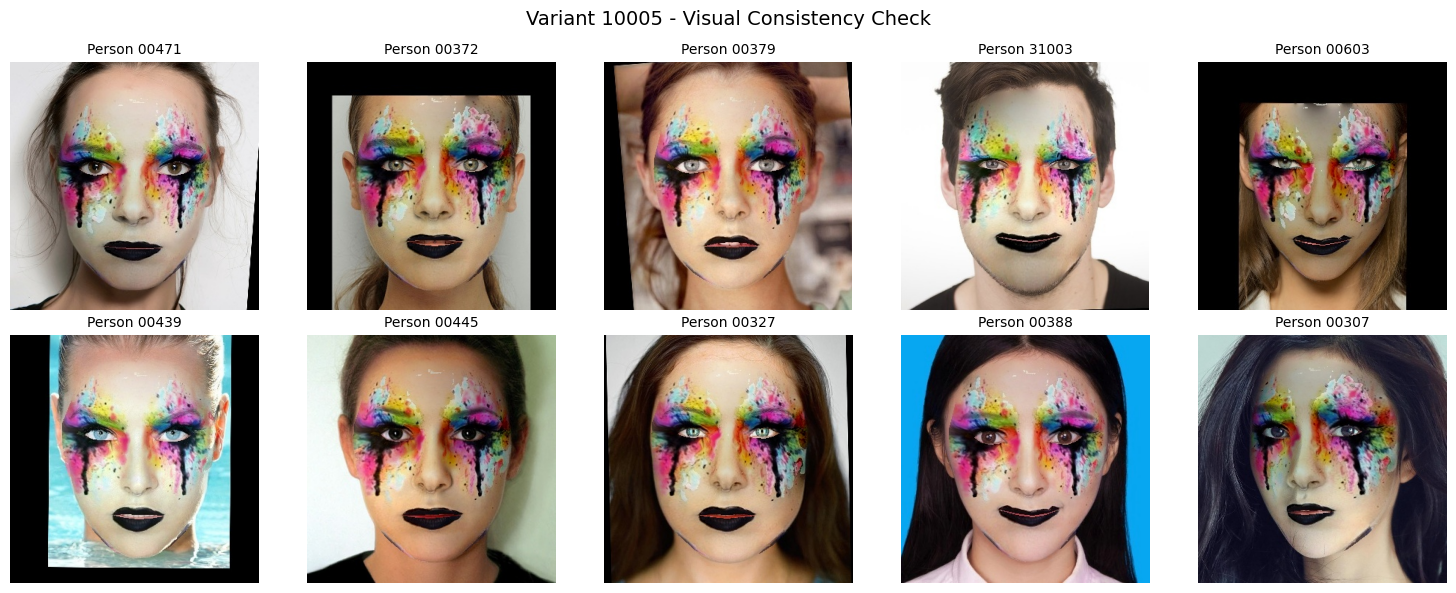

In [47]:
def show_variant_across_people(makeup_data, target_variant="10005", max_people=10):
    """Show specific variant across different people for visual comparison."""
    if not makeup_data:
        print("No makeup data available!")
        return
    
    # Find people who have the target variant
    people_with_variant = []
    for person_id, variants in makeup_data.items():
        for variant_info in variants:
            if variant_info['variant_id'] == target_variant:
                people_with_variant.append({
                    'person_id': person_id,
                    'path': variant_info['full_path']
                })
                break
    
    if not people_with_variant:
        print(f"Variant {target_variant} not found in any person!")
        return
    
    # Limit to max_people
    people_with_variant = people_with_variant[:max_people]
    
    print(f"Showing variant {target_variant} across {len(people_with_variant)} people:")
    
    # Display in 2 rows of 5
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for idx, person_info in enumerate(people_with_variant):
        try:
            img = Image.open(person_info['path'])
            axes[idx].imshow(img)
            axes[idx].set_title(f"Person {person_info['person_id']}", fontsize=10)
            axes[idx].axis('off')
        except Exception as e:
            axes[idx].text(0.5, 0.5, f"Error\n{person_info['person_id']}", 
                         ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(len(people_with_variant), 10):
        axes[idx].axis('off')
    
    plt.suptitle(f'Variant {target_variant} - Visual Consistency Check', fontsize=14)
    plt.tight_layout()
    plt.show()

# Show variant 10005 across 10 people
if makeup_blend_data:
    show_variant_across_people(makeup_blend_data, target_variant="10005", max_people=10)
else:
    print("No makeup blend data loaded!")

### Testing All Datasets
Test loading and display sample results from all three datasets to verify everything works correctly.

In [45]:
def test_all_datasets():
    """
    Test all three datasets and display sample images to verify loading works correctly.
    """
    print("="*50)
    print("DATASET TESTING SUMMARY")
    print("="*50)
    
    # Test FFHQ-Makeup dataset
    print("\n1. FFHQ-Makeup Dataset Test:")
    if ffhq_makeup_data:
        print(f"✓ Successfully loaded {len(ffhq_makeup_data)} samples")
        
        # Try to load a sample image
        sample = ffhq_makeup_data[0]
        try:
            if sample['bare_image'] and os.path.exists(sample['bare_image']):
                img = Image.open(sample['bare_image'])
                print(f"✓ Successfully opened sample bare image: {img.size}")
            else:
                print("⚠ Bare image path not valid")
                
            if sample['makeup_variants']:
                variant_path = sample['makeup_variants'][0]
                if os.path.exists(variant_path):
                    img = Image.open(variant_path)
                    print(f"✓ Successfully opened sample makeup variant: {img.size}")
                else:
                    print("⚠ Makeup variant path not valid")
        except Exception as e:
            print(f"✗ Error loading FFHQ-Makeup images: {e}")
    else:
        print("✗ No FFHQ-Makeup data loaded")
    
    # Test Makeup Blend dataset
    print("\n2. Makeup Blend Dataset Test:")
    if makeup_blend_data:
        print(f"✓ Successfully loaded {len(makeup_blend_data)} people")
        
        # Try to load a sample image
        sample_person = list(makeup_blend_data.keys())[0]
        sample_variant = makeup_blend_data[sample_person][0]
        try:
            if os.path.exists(sample_variant['full_path']):
                img = Image.open(sample_variant['full_path'])
                print(f"✓ Successfully opened sample blend image: {img.size}")
                print(f"  Person: {sample_person}, Variant: {sample_variant['variant_id']}")
            else:
                print("⚠ Sample blend image path not valid")
        except Exception as e:
            print(f"✗ Error loading makeup blend images: {e}")
    else:
        print("✗ No makeup blend data loaded")
    
    # Test Natural Data dataset
    print("\n3. Natural Data Dataset Test:")
    if natural_data['no_makeup'] or natural_data['with_makeup']:
        print(f"✓ Successfully loaded natural data")
        print(f"  No makeup: {len(natural_data['no_makeup'])} images")
        print(f"  With makeup: {len(natural_data['with_makeup'])} images")
        
        # Try to load sample images
        try:
            if natural_data['no_makeup']:
                img = Image.open(natural_data['no_makeup'][0])
                print(f"✓ Successfully opened sample no_makeup image: {img.size}")
            
            if natural_data['with_makeup']:
                img = Image.open(natural_data['with_makeup'][0])
                print(f"✓ Successfully opened sample with_makeup image: {img.size}")
        except Exception as e:
            print(f"✗ Error loading natural data images: {e}")
    else:
        print("✗ No natural data loaded")
    
    # Overall summary
    print("\n" + "="*50)
    print("OVERALL RESULTS:")
    total_images = 0
    
    if ffhq_makeup_data:
        ffhq_count = sum(1 + len(sample['makeup_variants']) for sample in ffhq_makeup_data)
        total_images += ffhq_count
        print(f"FFHQ-Makeup: ~{ffhq_count} images from {len(ffhq_makeup_data)} people")
    
    if makeup_blend_data:
        blend_count = sum(len(variants) for variants in makeup_blend_data.values())
        total_images += blend_count
        print(f"Makeup Blend: {blend_count} images from {len(makeup_blend_data)} people")
    
    natural_count = len(natural_data['no_makeup']) + len(natural_data['with_makeup'])
    total_images += natural_count
    print(f"Natural Data: {natural_count} images")
    
    print(f"\nTotal estimated images available: {total_images}")
    print("="*50)

# Run the test
test_all_datasets()

DATASET TESTING SUMMARY

1. FFHQ-Makeup Dataset Test:
✓ Successfully loaded 100 samples
✓ Successfully opened sample bare image: (512, 512)
✓ Successfully opened sample makeup variant: (512, 512)

2. Makeup Blend Dataset Test:
✓ Successfully loaded 100 people
✓ Successfully opened sample blend image: (315, 315)
  Person: 00471, Variant: 00001

3. Natural Data Dataset Test:
✓ Successfully loaded natural data
  No makeup: 26 images
  With makeup: 26 images
✓ Successfully opened sample no_makeup image: (1000, 1333)
✓ Successfully opened sample with_makeup image: (1000, 1333)

OVERALL RESULTS:
FFHQ-Makeup: ~600 images from 100 people
Makeup Blend: 37502 images from 100 people
Natural Data: 52 images

Total estimated images available: 38154


## Age Estimation Experiment on FFHQ Dataset

Now we'll run our experiment using the trained age estimation model on the FFHQ dataset to analyze how makeup affects age perception.

In [48]:
def predict_age_from_path(image_path, model, transform, device):
    """
    Predict age from an image file path using the trained model.
    
    Args:
        image_path: Path to the image file
        model: Trained PyTorch model
        transform: Image preprocessing transforms
        device: PyTorch device (CPU/CUDA)
    
    Returns:
        Predicted age as float, or None if error
    """
    try:
        # Load and preprocess image
        image = Image.open(image_path).convert('RGB')
        
        # Apply transforms
        image_tensor = transform(image).unsqueeze(0).to(device)
        
        # Predict
        model.eval()
        with torch.no_grad():
            prediction = model(image_tensor).squeeze().item()
        
        return max(0, prediction)  # Ensure non-negative age
        
    except Exception as e:
        print(f"Error predicting age for {image_path}: {e}")
        return None

def run_ffhq_age_experiment(ffhq_data, model, transform, device, max_people=100):
    """
    Run age estimation experiment on FFHQ dataset.
    
    Args:
        ffhq_data: FFHQ dataset list
        model: Trained age estimation model
        transform: Image preprocessing transforms
        device: PyTorch device
        max_people: Maximum number of people to test
    
    Returns:
        Dictionary with experiment results
    """
    results = {
        'people_tested': [],
        'successful_predictions': 0,
        'failed_predictions': 0,
        'total_variance': 0,
        'individual_variances': [],
        'base_ages': [],
        'makeup_ages': []
    }
    
    print(f"Starting FFHQ age estimation experiment on {min(max_people, len(ffhq_data))} people...")
    
    # Limit to max_people
    people_to_test = ffhq_data[:max_people]
    
    for i, person_data in enumerate(tqdm(people_to_test, desc="Processing people")):
        person_id = person_data.get('person_id', f'person_{i}')
        
        person_results = {
            'person_id': person_id,
            'base_age': None,
            'makeup_ages': [],
            'variance': None,
            'successful': False
        }
        
        # Predict age for base image
        if person_data['bare_image'] and os.path.exists(person_data['bare_image']):
            base_age = predict_age_from_path(person_data['bare_image'], model, transform, device)
            person_results['base_age'] = base_age
            
            if base_age is not None:
                results['base_ages'].append(base_age)
                
                # Predict ages for makeup variants
                makeup_ages = []
                for variant_path in person_data['makeup_variants']:
                    if os.path.exists(variant_path):
                        makeup_age = predict_age_from_path(variant_path, model, transform, device)
                        if makeup_age is not None:
                            makeup_ages.append(makeup_age)
                            results['makeup_ages'].append(makeup_age)
                
                person_results['makeup_ages'] = makeup_ages
                
                # Calculate variance if we have both base and makeup predictions
                if len(makeup_ages) > 0:
                    # Calculate variance between base age and each makeup variant
                    differences = [abs(base_age - makeup_age) for makeup_age in makeup_ages]
                    person_variance = np.var(differences) if len(differences) > 1 else 0
                    person_results['variance'] = person_variance
                    person_results['successful'] = True
                    
                    results['individual_variances'].append(person_variance)
                    results['total_variance'] += person_variance
                    results['successful_predictions'] += 1
                else:
                    results['failed_predictions'] += 1
            else:
                results['failed_predictions'] += 1
        else:
            results['failed_predictions'] += 1
            
        results['people_tested'].append(person_results)
        
        # Print progress every 20 people
        if (i + 1) % 20 == 0:
            print(f"Processed {i + 1}/{len(people_to_test)} people. "
                  f"Successful: {results['successful_predictions']}, "
                  f"Failed: {results['failed_predictions']}")
    
    return results

print("Age prediction and experiment functions defined!")
print("Ready to run experiment on FFHQ dataset.")

Age prediction and experiment functions defined!
Ready to run experiment on FFHQ dataset.


In [51]:
def analyze_experiment_results(results):
    """
    Analyze the results from the FFHQ age estimation experiment.
    
    Args:
        results: Results dictionary from run_ffhq_age_experiment
        
    Returns:
        Dictionary with detailed analysis
    """
    analysis = {
        'summary': {},
        'statistics': {},
        'detailed_analysis': {}
    }
    
    # Basic summary
    total_people = len(results['people_tested'])
    successful = results['successful_predictions']
    failed = results['failed_predictions']
    
    analysis['summary'] = {
        'total_people_tested': total_people,
        'successful_predictions': successful,
        'failed_predictions': failed,
        'success_rate': (successful / total_people * 100) if total_people > 0 else 0
    }
    
    # Statistical analysis
    if results['base_ages'] and results['makeup_ages']:
        base_ages = np.array(results['base_ages'])
        makeup_ages = np.array(results['makeup_ages'])
        individual_variances = np.array(results['individual_variances'])
        
        analysis['statistics'] = {
            'base_age_stats': {
                'mean': np.mean(base_ages),
                'median': np.median(base_ages),
                'std': np.std(base_ages),
                'min': np.min(base_ages),
                'max': np.max(base_ages)
            },
            'makeup_age_stats': {
                'mean': np.mean(makeup_ages),
                'median': np.median(makeup_ages),
                'std': np.std(makeup_ages),
                'min': np.min(makeup_ages),
                'max': np.max(makeup_ages)
            },
            'variance_stats': {
                'mean_variance': np.mean(individual_variances),
                'median_variance': np.median(individual_variances),
                'std_variance': np.std(individual_variances),
                'min_variance': np.min(individual_variances),
                'max_variance': np.max(individual_variances)
            },
            'age_difference_analysis': {
                'mean_absolute_difference': np.mean([abs(base - makeup) for base, makeup in zip(base_ages, makeup_ages[:len(base_ages)])]),
                'overall_age_shift': np.mean(makeup_ages) - np.mean(base_ages)
            }
        }
        
        # Detailed per-person analysis
        successful_people = [p for p in results['people_tested'] if p['successful']]
        
        # Find people with highest and lowest variance
        if successful_people:
            variances_with_people = [(p['variance'], p['person_id'], p['base_age'], p['makeup_ages']) 
                                   for p in successful_people if p['variance'] is not None]
            
            if variances_with_people:
                # Sort by variance
                variances_with_people.sort(key=lambda x: x[0])
                
                analysis['detailed_analysis'] = {
                    'lowest_variance_people': variances_with_people[:5],  # Top 5 most consistent
                    'highest_variance_people': variances_with_people[-5:],  # Top 5 most variable
                    'people_with_age_increase': [p for p in successful_people 
                                               if p['base_age'] and p['makeup_ages'] 
                                               and np.mean(p['makeup_ages']) > p['base_age']],
                    'people_with_age_decrease': [p for p in successful_people 
                                               if p['base_age'] and p['makeup_ages'] 
                                               and np.mean(p['makeup_ages']) < p['base_age']]
                }
    
    return analysis

def display_experiment_results(results, analysis):
    """
    Display the experiment results in a formatted way.
    """
    print("="*60)
    print("FFHQ AGE ESTIMATION EXPERIMENT RESULTS")
    print("="*60)
    
    # Summary
    summary = analysis['summary']
    print(f"\n📊 EXPERIMENT SUMMARY:")
    print(f"Total people tested: {summary['total_people_tested']}")
    print(f"Successful predictions: {summary['successful_predictions']}")
    print(f"Failed predictions: {summary['failed_predictions']}")
    print(f"Success rate: {summary['success_rate']:.1f}%")
    
    # Statistics
    if 'statistics' in analysis and analysis['statistics']:
        stats = analysis['statistics']
        
        print(f"\n📈 AGE STATISTICS:")
        base_stats = stats['base_age_stats']
        makeup_stats = stats['makeup_age_stats']
        variance_stats = stats['variance_stats']
        
        print(f"Base Images - Mean Age: {base_stats['mean']:.1f} ± {base_stats['std']:.1f} years")
        print(f"             Range: {base_stats['min']:.1f} - {base_stats['max']:.1f} years")
        
        print(f"Makeup Images - Mean Age: {makeup_stats['mean']:.1f} ± {makeup_stats['std']:.1f} years")
        print(f"               Range: {makeup_stats['min']:.1f} - {makeup_stats['max']:.1f} years")
        
        print(f"\n🔄 VARIANCE ANALYSIS:")
        print(f"Mean variance per person: {variance_stats['mean_variance']:.3f}")
        print(f"Median variance per person: {variance_stats['median_variance']:.3f}")
        print(f"Variance range: {variance_stats['min_variance']:.3f} - {variance_stats['max_variance']:.3f}")
        
        diff_analysis = stats['age_difference_analysis']
        print(f"\n📏 AGE DIFFERENCE ANALYSIS:")
        print(f"Mean absolute difference (base vs makeup): {diff_analysis['mean_absolute_difference']:.2f} years")
        print(f"Overall age shift (makeup effect): {diff_analysis['overall_age_shift']:.2f} years")
        
        if diff_analysis['overall_age_shift'] > 0:
            print("   → Makeup tends to make people appear OLDER")
        elif diff_analysis['overall_age_shift'] < 0:
            print("   → Makeup tends to make people appear YOUNGER")
        else:
            print("   → Makeup has no significant age effect on average")
    
    # Detailed analysis
    if 'detailed_analysis' in analysis and analysis['detailed_analysis']:
        detailed = analysis['detailed_analysis']
        
        print(f"\n🔍 DETAILED ANALYSIS:")
        
        print(f"\n👥 Age Effect Distribution:")
        age_increase = len(detailed['people_with_age_increase'])
        age_decrease = len(detailed['people_with_age_decrease'])
        total_analyzed = age_increase + age_decrease
        
        if total_analyzed > 0:
            print(f"People appearing older with makeup: {age_increase} ({age_increase/total_analyzed*100:.1f}%)")
            print(f"People appearing younger with makeup: {age_decrease} ({age_decrease/total_analyzed*100:.1f}%)")
        
        # Show most consistent people
        if detailed['lowest_variance_people']:
            print(f"\n✅ Most Consistent (Lowest Variance):")
            for i, (variance, person_id, base_age, makeup_ages) in enumerate(detailed['lowest_variance_people'][:3]):
                avg_makeup_age = np.mean(makeup_ages)
                print(f"  {i+1}. Person {person_id}: Variance={variance:.3f}, "
                      f"Base={base_age:.1f}, Makeup Avg={avg_makeup_age:.1f}")
        
        # Show most variable people
        if detailed['highest_variance_people']:
            print(f"\n❗ Most Variable (Highest Variance):")
            for i, (variance, person_id, base_age, makeup_ages) in enumerate(detailed['highest_variance_people'][-3:]):
                avg_makeup_age = np.mean(makeup_ages)
                print(f"  {i+1}. Person {person_id}: Variance={variance:.3f}, "
                      f"Base={base_age:.1f}, Makeup Avg={avg_makeup_age:.1f}")
    
    print("\n" + "="*60)

print("Analysis and display functions defined!")
print("Ready to analyze experiment results.")

Analysis and display functions defined!
Ready to analyze experiment results.


In [52]:
# Check if we have everything needed for the experiment
print("Checking experiment requirements...")

# Check if we have the datasets
if 'ffhq_makeup_data' in locals() and ffhq_makeup_data:
    print(f"✅ FFHQ dataset loaded: {len(ffhq_makeup_data)} people")
else:
    print("❌ FFHQ dataset not loaded")

# Check if we have the trained model
if 'trained_model' in locals() and trained_model:
    print("✅ Trained model available")
    model_to_use = trained_model
else:
    print("⚠️  No trained_model variable, using base model")
    model_to_use = model

# Check if we have the preprocessing transforms
if 'val_transform' in locals() and val_transform:
    print("✅ Validation transforms available")
    transform_to_use = val_transform
else:
    print("⚠️  Creating basic transforms")
    transform_to_use = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# Check device
if 'device' in locals():
    print(f"✅ Device available: {device}")
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"⚠️  Setting device to: {device}")

print("\nAll requirements checked. Ready to run experiment!")

Checking experiment requirements...
✅ FFHQ dataset loaded: 100 people
✅ Trained model available
✅ Validation transforms available
✅ Device available: cuda

All requirements checked. Ready to run experiment!


In [53]:
# Run the FFHQ age estimation experiment
print("🚀 Starting FFHQ Age Estimation Experiment")
print("="*60)
print(f"Testing {len(ffhq_makeup_data)} people from FFHQ dataset")
print(f"Each person has 1 base image + 5 makeup variants = 6 images total")
print(f"Expected total predictions: {len(ffhq_makeup_data) * 6}")
print("="*60)

# Run the experiment
experiment_results = run_ffhq_age_experiment(
    ffhq_data=ffhq_makeup_data,
    model=model_to_use,
    transform=transform_to_use,
    device=device,
    max_people=100  # Test all 100 people
)

print("\n✅ Experiment completed!")
print(f"Successful predictions: {experiment_results['successful_predictions']}")
print(f"Failed predictions: {experiment_results['failed_predictions']}")

# Analyze the results
print("\n🔬 Analyzing results...")
analysis_results = analyze_experiment_results(experiment_results)

# Display comprehensive results
display_experiment_results(experiment_results, analysis_results)

🚀 Starting FFHQ Age Estimation Experiment
Testing 100 people from FFHQ dataset
Each person has 1 base image + 5 makeup variants = 6 images total
Expected total predictions: 600
Starting FFHQ age estimation experiment on 100 people...


Processing people:  21%|██        | 21/100 [00:03<00:10,  7.20it/s]

Processed 20/100 people. Successful: 20, Failed: 0


Processing people:  41%|████      | 41/100 [00:05<00:08,  6.90it/s]

Processed 40/100 people. Successful: 40, Failed: 0


...

Processed 60/100 people. Successful: 60, Failed: 0


Processing people:  81%|████████  | 81/100 [00:11<00:02,  6.87it/s]

Processed 80/100 people. Successful: 80, Failed: 0


Processing people: 100%|██████████| 100/100 [00:14<00:00,  6.86it/s]

Processed 100/100 people. Successful: 100, Failed: 0

✅ Experiment completed!
Successful predictions: 100
Failed predictions: 0

🔬 Analyzing results...
FFHQ AGE ESTIMATION EXPERIMENT RESULTS

📊 EXPERIMENT SUMMARY:
Total people tested: 100
Successful predictions: 100
Failed predictions: 0
Success rate: 100.0%

📈 AGE STATISTICS:
Base Images - Mean Age: 29.1 ± 19.9 years
             Range: 1.2 - 73.6 years
Makeup Images - Mean Age: 17.7 ± 8.3 years
               Range: 2.1 - 57.5 years

🔄 VARIANCE ANALYSIS:
Mean variance per person: 14.743
Median variance per person: 3.309
Variance range: 0.137 - 261.575

📏 AGE DIFFERENCE ANALYSIS:
Mean absolute difference (base vs makeup): 17.37 years
Overall age shift (makeup effect): -11.47 years
   → Makeup tends to make people appear YOUNGER

🔍 DETAILED ANALYSIS:

👥 Age Effect Distribution:
People appearing older with makeup: 33 (33.0%)
People appearing younger with makeup: 67 (67.0%)

✅ Most Consistent (Lowest Variance):
  1. Person 058647: Varian